У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import operator
import os
import pandas as pd
import seaborn as sns
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, mean_squared_error, roc_curve, auc, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler, StandardScaler, TargetEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

**Завантаження даних**

In [2]:
raw_df = pd.read_csv("data/customer_segmentation_train.csv", index_col=0)

**Аналіз датасету**

In [3]:
raw_df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
ID,,,,,,,,,,
462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [4]:
raw_df.shape

(8068, 10)

In [5]:
raw_df.isna().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8068 entries, 462809 to 461879
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     7928 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   object 
 4   Profession       7944 non-null   object 
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      7733 non-null   float64
 8   Var_1            7992 non-null   object 
 9   Segmentation     8068 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 693.3+ KB


In [7]:
raw_df.describe()

,Age,Work_Experience,Family_Size
count,8068.000000,7239.000000,7733.000000
mean,43.466906,2.641663,2.850123
std,16.711696,3.406763,1.531413
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


<Axes: >

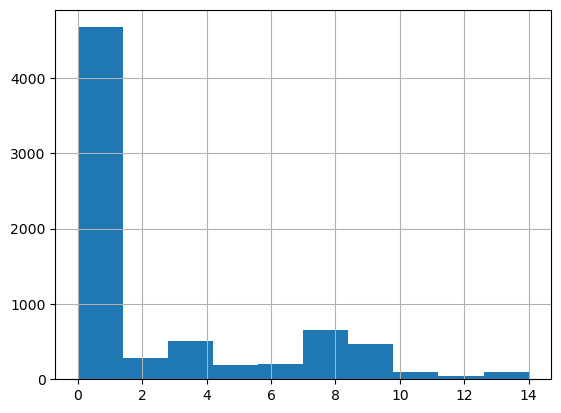

In [8]:
raw_df.Work_Experience.hist()

<Axes: >

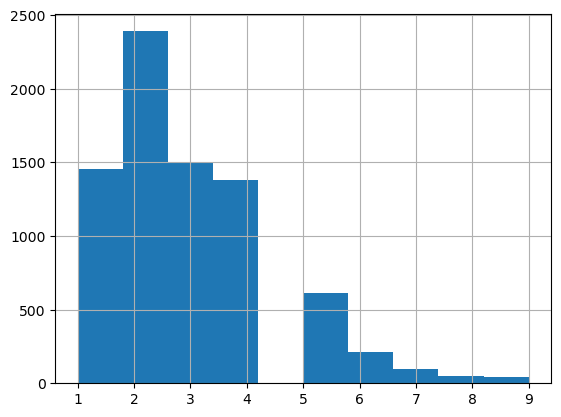

In [9]:
raw_df.Family_Size.hist()

In [10]:
raw_df.Profession.value_counts()

Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

In [11]:
raw_df.Var_1.value_counts()

Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64

**Попередня обробка даних**

In [12]:
train_df, test_df = train_test_split(raw_df, test_size=0.2, stratify=raw_df["Segmentation"], random_state=42)

In [13]:
input_cols = list(train_df.columns)[:-1]
target_col = 'Segmentation'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
test_inputs, test_targets = test_df[input_cols].copy(), test_df[target_col].copy()

In [14]:
# Виявляємо числові і категоріальні колонки
num_features = train_inputs.select_dtypes(include=np.number).columns.tolist()
cat_features = train_inputs.select_dtypes(include='object').columns.tolist()
# Індекси числових і категоріальних колонок
num_indices = [i for i, col in enumerate(num_features + cat_features) if col in num_features]
cat_indices = [i for i, col in enumerate(num_features + cat_features) if col in cat_features]

**Створення пайплайнів для кожного випадку підготовки даних з ресамплингои і без**

In [15]:
#PIPELINE 1 — Original data (no resampling)

# Створюємо трансформер для числових і категоріальних колонок
preprocess_original = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_features),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_features)
    ]
)


# Стоврюємо пайплайн, який спочатку запускає препроцесинг
pipeline_original = Pipeline([
    ("preprocess", preprocess_original),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=500)))
])


# Тренуємо пайплайн
pipeline_original.fit(train_inputs, train_targets)

# Зберігаємо модель для подальшого використання
joblib.dump(pipeline_original, 'multi_log_model_pipeline.joblib')

['multi_log_model_pipeline.joblib']

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [16]:
#PIPELINE 2 — SMOTENC data

# Створюємо трансформер для числових і категоріальних колонок перед апсемплингом
pre_smote = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_features)
    ]
)

# SMOTENC апсемплинг
smotenc = SMOTENC(categorical_features=cat_indices, random_state=42)

# Створюємо трансформер для числових і категоріальних колонок після апсемплингу
post_smote = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_indices),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_indices)
    ]
)

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
pipeline_smotenc = ImbPipeline([
    ("pre_smote", pre_smote),
    ("smotenc", smotenc),
    ("post_smote", post_smote),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=500)))
])

# Тренуємо пайплайн
pipeline_smotenc.fit(train_inputs, train_targets)

# Зберігаємо модель для подальшого використання
joblib.dump(pipeline_smotenc, 'smotenc_multi_log_model_pipeline.joblib')

['smotenc_multi_log_model_pipeline.joblib']

In [17]:
#PIPELINE 3 — SMOTE-Tomek data

# Створюємо трансформер для числових і категоріальних колонок перед ресамплингом
pre_smote_tomek = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_features)
    ]
)

# SMOTE-Tomek ресамплинг
smote_tomek = SMOTETomek(random_state=42)

# Створюємо трансформер для числових і категоріальних колонок після ресамплингу
post_smote_tomek = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_indices),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_indices)
    ]
)

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
pipeline_smote_tomek = ImbPipeline([
    ("pre_smote_tomek", pre_smote_tomek),
    ("smote_tomek", smote_tomek),
    ("post_smote_tomek", post_smote_tomek),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=500)))
])

# Тренуємо пайплайн
pipeline_smote_tomek.fit(train_inputs, train_targets)

# Зберігаємо модель для подальшого використання
joblib.dump(pipeline_smote_tomek, 'smote_tomek_multi_log_model_pipeline.joblib')

['smote_tomek_multi_log_model_pipeline.joblib']

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

**Навчаю модель логістичної регресії і вивовджу classification_report.**

In [19]:
# 1. Завантажуємо моделі
model_original = joblib.load("multi_log_model_pipeline.joblib")
model_smotenc = joblib.load("smotenc_multi_log_model_pipeline.joblib")
model_smotetomek = joblib.load("smote_tomek_multi_log_model_pipeline.joblib")

# 2. Робимо передбачення
pred_original = model_original.predict(test_inputs)
pred_smotenc = model_smotenc.predict(test_inputs)
pred_smotetomek = model_smotetomek.predict(test_inputs)

# 3. Виводимо classification_report
print("=== ORIGINAL DATA ===")
print(classification_report(test_targets, pred_original))

print("\n=== SMOTENC DATA ===")
print(classification_report(test_targets, pred_smotenc))

print("\n=== SMOTE-TOMEK DATA ===")
print(classification_report(test_targets, pred_smotetomek))

=== ORIGINAL DATA ===
              precision    recall  f1-score   support

           A       0.41      0.45      0.43       394
           B       0.40      0.17      0.24       372
           C       0.49      0.61      0.54       394
           D       0.64      0.76      0.70       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.49      0.51      0.49      1614


=== SMOTENC DATA ===
              precision    recall  f1-score   support

           A       0.42      0.47      0.44       394
           B       0.42      0.26      0.32       372
           C       0.52      0.59      0.55       394
           D       0.67      0.72      0.69       454

    accuracy                           0.52      1614
   macro avg       0.51      0.51      0.50      1614
weighted avg       0.51      0.52      0.51      1614


=== SMOTE-TOMEK DATA ===
              precision    recall  f1-score   support

     

**Accuracy**
| Модель          | Accuracy |
|-----------------|----------|
| Original        | **0.51** |
| SMOTENC         | **0.52** |
| SMOTE‑Tomek     | **0.51** |

SMOTENC дає невелике, але стабільне покращення.

**Macro F1** (найважливіша метрика при imbalance)
| Модель          | Macro F1 |
|-----------------|----------|
| Original        | **0.48** |
| SMOTENC         | **0.50** |
| SMOTE‑Tomek     | **0.49** |

SMOTENC найбільш суттєве покращення.

**Поведінка по класах**
| Клас            | Спостереження                                        |
|-----------------|------------------------------------------------------|
| Клас A          | SMOTENC і SMOTE‑Tomek - Легке покращення             |
| Клас B          | SMOTENC дає найбільший приріст (+0.08)               |
| Клас С          | SMOTENC - Легке покращення                           |
| Клас D          | Клас D і так був найкращим - SMOTENC не дає приросту |

Чому SMOTENC працює краще?
- Він враховує категоріальні ознаки.  
- Не створює нереалістичних точок у змішаному просторі.  
- Не видаляє Tomek‑links, які інколи корисні для моделі.  

SMOTE‑Tomek інколи перечищає дані, видаляючи важливі прикордонні точки.

**Висновок**:
SMOTENC — найкращий метод балансування для цієї задачі. Він дає:
- найвищий macro F1
- найкращу якість для найскладнішого класу B  
- стабільне покращення accuracy  
- мінімальне спотворення структури даних.

**Гіпотеза**: чому моделі майже не відрізняються:
1. Дані вже достатньо збалансовані
2. Логістична регресія - лінійна модель, і її межі мало змінюються
3. Проблемний клас B має низьку віддільність, його ознаки перекриваються з іншими класами, проблема не в дисбалансі, а в структурі ознак
4. SMOTE‑Tomek іноді може видаляти корисні прикордонні точки
5. Якість обмежена самими ознаками. Якщо фічі: слабко корелюють з класами, містять мало інформації або мають сильний шум, то жоден метод балансування не дасть великого приросту. У таких випадках допомагає не SMOTE, а інженерія ознак, додаткові дані або нелінійні моделі (Random Forest, XGBoost).

Різниця між моделями мінімальна, тому що дисбаланс класів не є головною проблемою задачі. Логістична регресія має лінійні межі, які мало змінюються після ресемплінгу. Найскладніший клас B погано відділяється від інших через структуру ознак, а не через нестачу прикладів. Тому SMOTENC і SMOTE‑Tomek не дають суттєвого приросту якості.

In [20]:
def transform_for_model(model, X):
    steps = model.named_steps

    if "preprocess" in steps:
        X_t = steps["preprocess"].transform(X)

    elif "pre_smote" in steps:
        X_t = steps["pre_smote"].transform(X)
        if "post_smote" in steps:
            X_t = steps["post_smote"].transform(X_t)

    elif "pre_smote_tomek" in steps:
        X_t = steps["pre_smote_tomek"].transform(X)
        if "post_smote_tomek" in steps:
            X_t = steps["post_smote_tomek"].transform(X_t)

    else:
        raise ValueError("Unknown pipeline structure")

    return X_t

def plot_decision_boundary_pca(model, X, y, ax, title):
    # === 1. Transform X using your helper ===
    X_t = transform_for_model(model, X)

    # === 2. PCA to 2D ===
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_t)

    # === 3. Create meshgrid ===
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # === 4. Inverse PCA → back to model feature space ===
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_original_space = pca.inverse_transform(grid)

    # === 5. Predict using Logistic Regression inside pipeline ===
    clf = model.named_steps["clf"]
    Z = clf.predict(grid_original_space)

    # === 6. Convert class labels to integers for contourf ===
    classes = np.unique(y)
    class_to_int = {cls: i for i, cls in enumerate(classes)}
    Z_numeric = np.vectorize(class_to_int.get)(Z).reshape(xx.shape)

    # === 7. Plot decision boundary ===
    ax.contourf(xx, yy, Z_numeric, alpha=0.3, cmap="coolwarm")

    # === 8. Plot PCA‑projected training points ===
    y_numeric = np.vectorize(class_to_int.get)(y)
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numeric, edgecolor='k', s=20)

    ax.set_title(title)

def plot_roc_all(ax, models, model_names, X_train, y_train, X_test, y_test):
    for model, name in zip(models, model_names):

        # 1. Transform data exactly as model does
        X_train_t = transform_for_model(model, X_train)
        X_test_t = transform_for_model(model, X_test)

        # 2. Use the SAME Logistic Regression classifier inside pipeline
        clf = model.named_steps["clf"]

        # 3. Predict probabilities
        y_score = clf.predict_proba(X_test_t)

        # 4. Compute macro-average ROC AUC
        classes = clf.classes_
        aucs = []

        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve((y_test == cls).astype(int), y_score[:, i])
            auc = roc_auc_score((y_test == cls).astype(int), y_score[:, i])
            aucs.append(auc)

            # Plot only class 0 curve for visual clarity
            if i == 0:
                ax.plot(fpr, tpr, label=f"{name} (macro AUC={np.mean(aucs):.3f})")

    ax.set_title("ROC Curves (All Models)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")

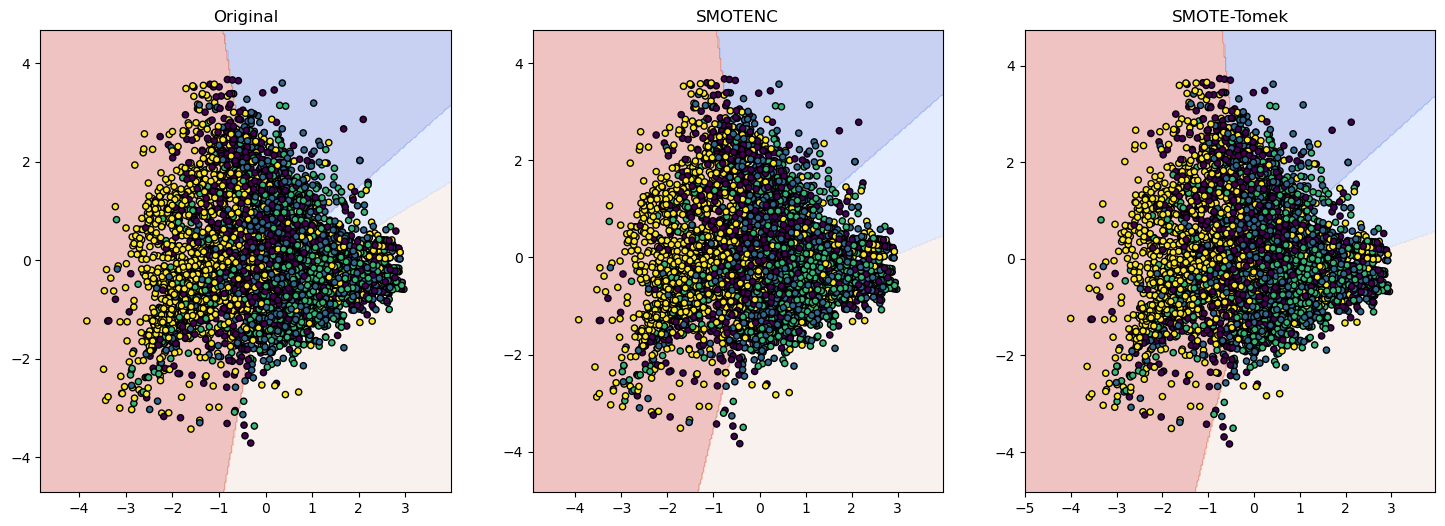

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_decision_boundary_pca(model_original, train_inputs, train_targets, axes[0], "Original")
plot_decision_boundary_pca(model_smotenc, train_inputs, train_targets, axes[1], "SMOTENC")
plot_decision_boundary_pca(model_smotetomek, train_inputs, train_targets, axes[2], "SMOTE-Tomek")

plt.show()

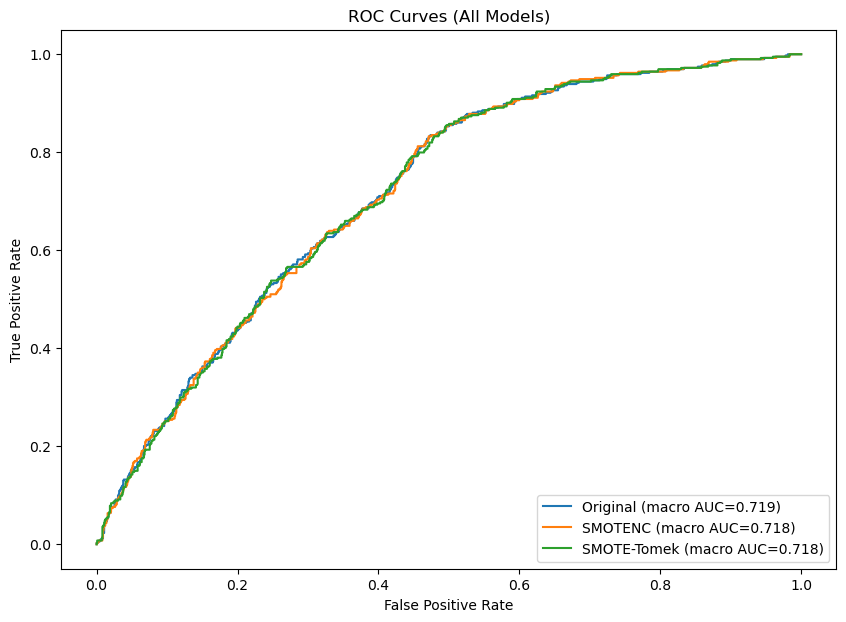

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_roc_all(
    ax,
    models=[model_original, model_smotenc, model_smotetomek],
    model_names=["Original", "SMOTENC", "SMOTE-Tomek"],
    X_train=train_inputs,
    y_train=train_targets,
    X_test=test_inputs,
    y_test=test_targets
)

plt.show()